In [1]:
import typing as tp
import sys
from pathlib import Path

import numpy as np
import polars as pl
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import logomaker
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '..')
import mpra_predictor

pl.Config(tbl_rows=15)
sns.set_theme(font_scale=1.5, palette='Set2')
sns.set_style('whitegrid')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_DIR = Path("../data")


### Data

Data preprocessing is done in the [`01_data_preprocess.py`](../scripts/01_data_preprocess.py) script.


In [2]:
# OL49 MPRA library
dataset = pl.read_csv(DATA_DIR / "OL49.csv")

dataset_train = dataset.filter(pl.col("split") == "train")
dataset_valid = dataset.filter(pl.col("split") == "val")
dataset_test = dataset.filter(pl.col("split") == "test")
print(f"Train size: {dataset_train.height}\nValidation size: {dataset_valid.height}\nTest size: {dataset_test.height}")

# there is no virus strain overlap between train / validation / test groups
assert dataset.select("strain").n_unique() == dataset.select("strain", "split").n_unique()


Train size: 47553
Validation size: 9377
Test size: 8098


### Trained MPRA predictor model

Training of the model is performed in the [`02_train_mpra_predictor.py`](../scripts/02_train_mpra_predictor.py)


In [3]:
def get_predictions(model: nn.Module, dataloader: DataLoader):
    model.eval()
    all_targets = []
    all_preds = []
    with torch.no_grad():
        for *x_batch, y_batch in tqdm(dataloader, desc="Inference", leave=False):
            preds = model(*x_batch)
            all_targets.append(y_batch.cpu())
            all_preds.append(preds.cpu())
    all_targets = torch.cat(all_targets).numpy()
    all_preds = torch.cat(all_preds).numpy()
    return all_targets, all_preds


def plot_predictions(
    ax: plt.Axes,
    valid_targets: np.ndarray, valid_preds: np.ndarray,
    test_targets: np.ndarray, test_preds: np.ndarray,
) -> plt.Axes:
    valid_mask = ~np.isnan(valid_targets)
    test_mask = ~np.isnan(test_targets)
    valid_targets, valid_preds = valid_targets[valid_mask], valid_preds[valid_mask]
    test_targets, test_preds = test_targets[test_mask], test_preds[test_mask]
    valid_r2, valid_pcc = r2_score(valid_targets, valid_preds), pearsonr(valid_targets, valid_preds).statistic
    test_r2, test_pcc = r2_score(test_targets, test_preds), pearsonr(test_targets, test_preds).statistic
    ax.scatter(valid_targets, valid_preds, alpha=.2, s=50, color='cornflowerblue', label=f'validation ($R^2$={valid_r2:.2}, PCC={valid_pcc:.2})')
    ax.scatter(test_targets, test_preds, alpha=.2, s=50, color='firebrick', label=f'test ($R^2$={test_r2:.2}, PCC={test_pcc:.2})')
    ax.plot([-1, 5.5], [-1, 5.5], 'black')
    ax.set_xlim([-1.5, 6.5])
    ax.set_ylim([-1.5, 6.5])
    ax.set_xlabel('Experiment', fontsize=20)
    ax.set_ylabel('Prediction', fontsize=20)
    ax.legend(loc='upper left')
    ax.grid(False)
    return ax


CONFIG = {
    'sei_pooler': {'n_heads': 1, 'hidden_dim': 128, 'pos_emb_dim': 8, 'dropout': 0.5, },
    'mal_pooler': {'n_heads': 1, 'hidden_dim': 64, 'pos_emb_dim': 8, 'dropout': 0.5, },
    'fusion': {'output_dim': 128, 'dropout': 0.7},
    'mlp': {'hidden_size': 128, 'num_res_blocks': 0, 'dropout': 0.5},
}


Load model and obtain predictions

In [4]:
# # A model trained to predict MPRA in Jurkat only
# CONFIG['target_columns'] = ['lfc_mean_Jurkat',]

# A model trained to predict MPRA in 6 cell lines
CONFIG['target_columns'] = ['lfc_mean_GM12878', 'lfc_mean_Jurkat', 'lfc_mean_MRC5', 'lfc_mean_A549', 'lfc_mean_HEK293', 'lfc_mean_K562']

model = mpra_predictor.load.load_model_structure(CONFIG, load_pretrained_base_weights=False).to(DEVICE)
model.load_state_dict(torch.load(DATA_DIR / f"trained_models/{str(model)}.pt", map_location=DEVICE), strict=True)
model.to(DEVICE)
model.eval()

sei_flank_builder = mpra_predictor.dataloader.prepare_flank_builder(input_size=4096)
mal_flank_builder = mpra_predictor.dataloader.prepare_flank_builder(input_size=600)
valid_dataset = mpra_predictor.dataloader.FusedDataset(dataframe=dataset_valid, target_columns=CONFIG['target_columns'], sei_flank_builder=sei_flank_builder, mal_flank_builder=mal_flank_builder, device=DEVICE,)
valid_loader = DataLoader(valid_dataset, batch_size=256)
test_dataset = mpra_predictor.dataloader.FusedDataset(dataframe=dataset_test, target_columns=CONFIG['target_columns'], sei_flank_builder=sei_flank_builder, mal_flank_builder=mal_flank_builder, device=DEVICE,)
test_loader = DataLoader(test_dataset, batch_size=256)

valid_targets, valid_preds = get_predictions(model, valid_loader)
test_targets, test_preds = get_predictions(model, test_loader)


Inference:   0%|          | 0/37 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Jurkat MPRA (6 cell lines model)')

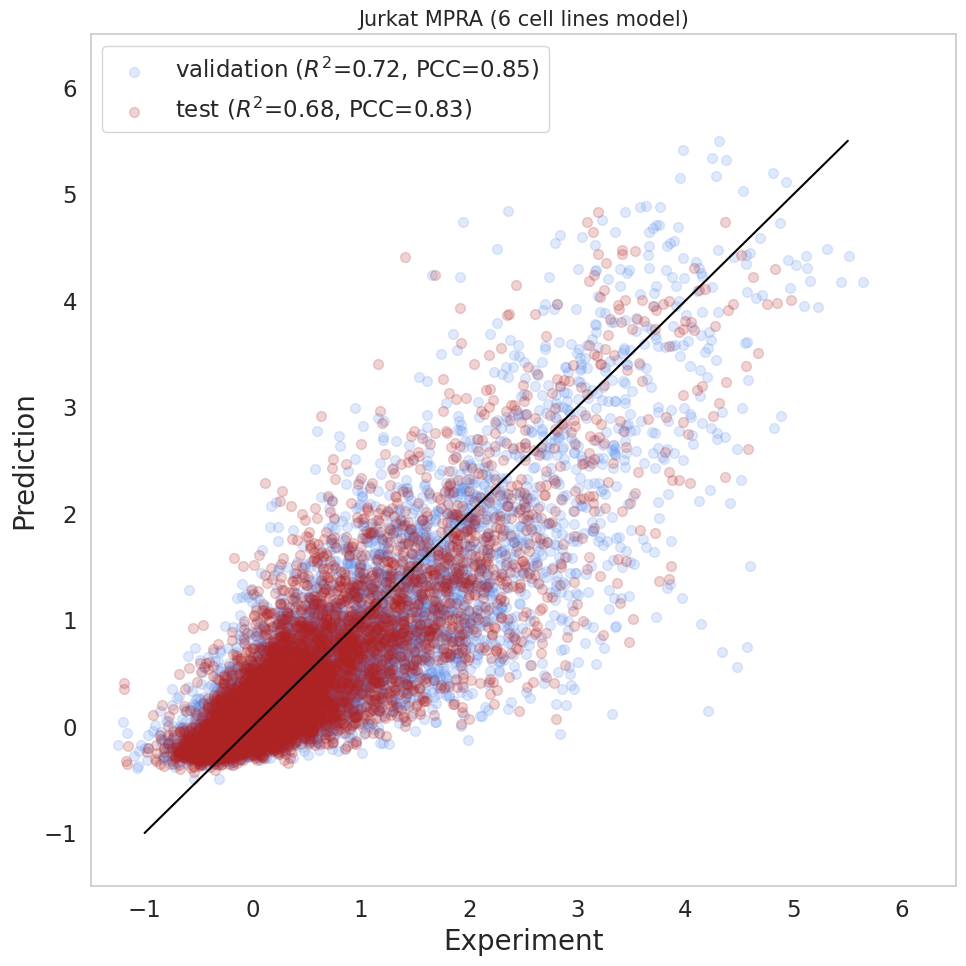

In [5]:
target_index = 1
target_label = CONFIG["target_columns"][target_index].split("_")[-1]

fig, ax = plt.subplots(figsize=(10, 10), layout="tight")
ax = plot_predictions(ax, valid_targets[:, target_index], valid_preds[:, target_index], test_targets[:, target_index], test_preds[:, target_index])
ax.set_title(f"{target_label} MPRA (6 cell lines model)", fontsize=15)
# fig.savefig(DATA_DIR / "baseline_model_jurkat_only.pdf", format="pdf", bbox_inches="tight")
# plt.close()


Control 1. Prediction strength per virus strain

In [6]:
per_strain_preds = list()
for set_name, targets, preds, set_df in [
    ['validation', valid_targets, valid_preds, dataset_valid],
    ['test', test_targets, test_preds, dataset_test],
]:
    for strain, strain_df in set_df.group_by('strain'):
        strain_targets = targets[set_df['strain'] == strain][:, target_index]
        strain_preds = preds[set_df['strain'] == strain][:, target_index]
        strain_r2 = r2_score(strain_targets, strain_preds)
        strain_pcc = pearsonr(strain_targets, strain_preds).statistic
        per_strain_preds.append([
            set_name, strain[0], strain_r2, strain_pcc
        ])
per_strain_preds = pl.DataFrame(per_strain_preds, orient="row", schema=['dataset', 'strain', f'r2 ({target_label} MPRA)', f'Pearson r ({target_label} MPRA)'])
per_strain_preds.sort('r2 (Jurkat MPRA)', descending=False)


dataset,strain,r2 (Jurkat MPRA),Pearson r (Jurkat MPRA)
str,str,f64,f64
"""validation""","""Papilloma_Virus:Type_18""",0.474538,0.719854
"""test""","""Papilloma_Virus:Type_11""",0.603563,0.780526
"""test""","""Herpesvirus:Kaposi_Sarcoma_[HH…",0.64939,0.811085
"""test""","""Human_T-Lymphoma_Virus:Type_3""",0.657866,0.818917
"""validation""","""Herpesvirus:Herpes_Simplex_1_K…",0.67449,0.824968
"""test""","""Polyomavirus:Merkel_Cell_Polyo…",0.693985,0.838059
"""validation""","""Adenovirus:Type_4_Strain_RI-67""",0.729429,0.858258
"""validation""","""HIV-2:GH-1""",0.739161,0.862969
"""validation""","""Adenovirus:Type_3_Strain_GB""",0.745399,0.865164


Control 2. Prediction of LTR core promoter tile across HIV-1 isolates (OL53 library)

**NOTE**: the model was trained on OL49 library experiment results. To match the OL53 scale we apply the OL49 $\rightarrow$ OL53 transformation learned using an independent set of control tiles exlcluded during the model training.

In [7]:
ol53_dataset = pl.read_csv(DATA_DIR / "OL53.csv")
tile_of_interest = 'HIV-1:REJO:6:'

tile_dataset = ol53_dataset.filter(ol53_dataset['ID'].str.contains(tile_of_interest) & (ol53_dataset['project'] == 'viral_satmut'))
tile_loader = DataLoader(
    mpra_predictor.dataloader.FusedDataset(dataframe=tile_dataset, target_columns=['lfc_mean_Jurkat'], sei_flank_builder=sei_flank_builder, mal_flank_builder=mal_flank_builder, device=DEVICE,),
    batch_size=256
)
tile_targets, tile_preds = get_predictions(model, tile_loader)
tile_targets = tile_targets[:, 0][:, None]
tile_preds = tile_preds[:, target_index][:, None]

# NOTE: learned transformation (Jurkat): OL53 ≈ 0.9210 * OL49 + 0.0547
tile_preds = 0.9210 * tile_preds + 0.0547


Inference:   0%|          | 0/3 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Isolates (HXB2: 250-431)')

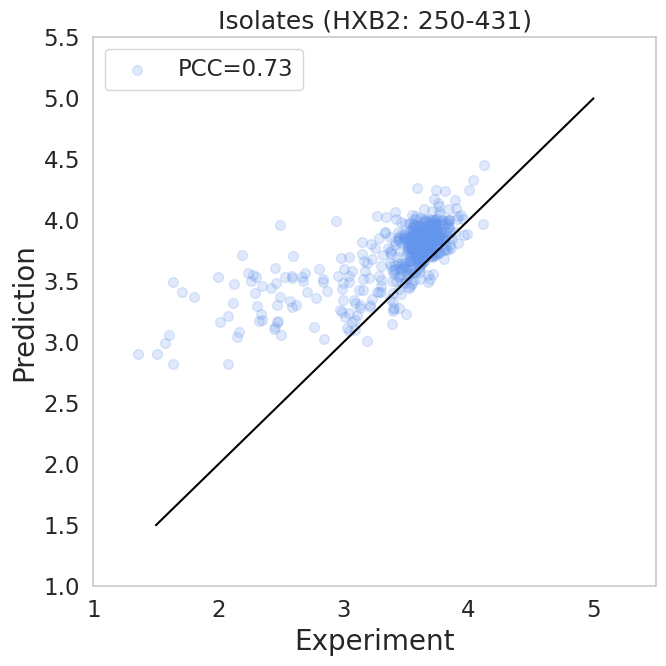

In [8]:
fig, ax = plt.subplots(figsize=(7, 7), layout="tight")
tile_pcc = pearsonr(tile_targets, tile_preds).statistic[0]
ax.scatter(tile_targets, tile_preds, alpha=.2, s=50, color='cornflowerblue', label=f'PCC={tile_pcc:.2}')
ax.plot([1.5, 5], [1.5, 5], 'black')
ax.set_xlim([1, 5.5])
ax.set_ylim([1, 5.5])
ax.set_xlabel('Experiment', fontsize=20)
ax.set_ylabel('Prediction', fontsize=20)
ax.legend(loc='upper left')
ax.grid(False)
ax.set_title("Isolates (HXB2: 250-431)")
# plt.close()


Control 3. Visualization of contribution scores for several tiles

In [9]:
control_tiles = []
for strain, tile_lst in [
    ['HIV-1:REJO', ['6:+', '9:+', '11:+', '13:+', '28:+', '157:+']],
    ['HIV-2:ROD', ['130:+', '185:+', '188:+', '208:-']],
    ['Human_T-Lymphoma_Virus:Type_1', ['2:+', '4:+', '10:+', '12:+', '130:+', '137:+']],
]:
    for tile in tile_lst:
        control_tiles.append(f"{strain}:{tile}")
control_tiles = dataset.filter(pl.col('ID').is_in(control_tiles))

mpra_interpreter = mpra_predictor.interpret.ModelInterpreter(model, target_index, batch_size=50, device=DEVICE)
for tile_id, tile_seq in control_tiles[['ID', 'sequence']].rows():
    mpra_interpreter.update(tile_id, tile_seq)
valid_ids, _, contribs = mpra_interpreter.get_predictions()
assert len(valid_ids) == len(control_tiles)


In [10]:
def rolling_absolute_contribution_scores(scores: np.ndarray, window: int = 10) -> np.ndarray:
    negative_sums = -scores.clip(max=0).sum(axis=0)
    positive_sums = scores.clip(min=0).sum(axis=0)
    total_abs_contrib = np.maximum(negative_sums, positive_sums)
    cumsum = np.cumsum(total_abs_contrib)
    half_window_left = (window + 1) // 2
    half_window_right = window // 2
    total_abs_contrib[half_window_left: -half_window_right] = (
        cumsum[window:] - cumsum[:-window]
    )
    return total_abs_contrib


def plot_contribution_scores(
    tile_id: str, tile_contribution_scores: tp.List[np.ndarray], targets: tp.List[str]
) -> plt.Figure:
    num_score_tracks = len(tile_contribution_scores)
    assert num_score_tracks == len(targets), "Number of contribution score tracks should equal to number of targets."
    fig, axes = plt.subplots(figsize=(18, 8), nrows=num_score_tracks, ncols=1,)
    for ax_idx, scores in enumerate(tile_contribution_scores):
        ax = axes[ax_idx] if len(tile_contribution_scores) > 1 else axes
        score_df = pl.DataFrame(scores.astype(np.float64).T, schema=["A", "C", "G", "T"]).to_pandas()
        logomaker.Logo(score_df, ax=ax, center_values=False)
        tacs = rolling_absolute_contribution_scores(scores, window=5)
        ax.plot(np.arange(200), tacs, color='cornflowerblue')
        if ax_idx == 0:
            ax.set_title(f"{tile_id}")
        ax.set_ylim([-1, 2.5])
        ax.set_xlim([0, 200])
        if ax_idx == num_score_tracks - 1:
            ax.set_xticks(np.arange(0, 201, 25))
            ax.set_xticklabels(np.arange(0, 201, 25))
            ax.tick_params(axis='x', bottom=True, labelbottom=True)
        else:
            ax.tick_params(axis='x', bottom=False, labelbottom=False)
        ax.set_ylabel(f'{targets[ax_idx]}')
        ax.grid(False)
    plt.subplots_adjust(wspace=0, hspace=0.1)
    return fig


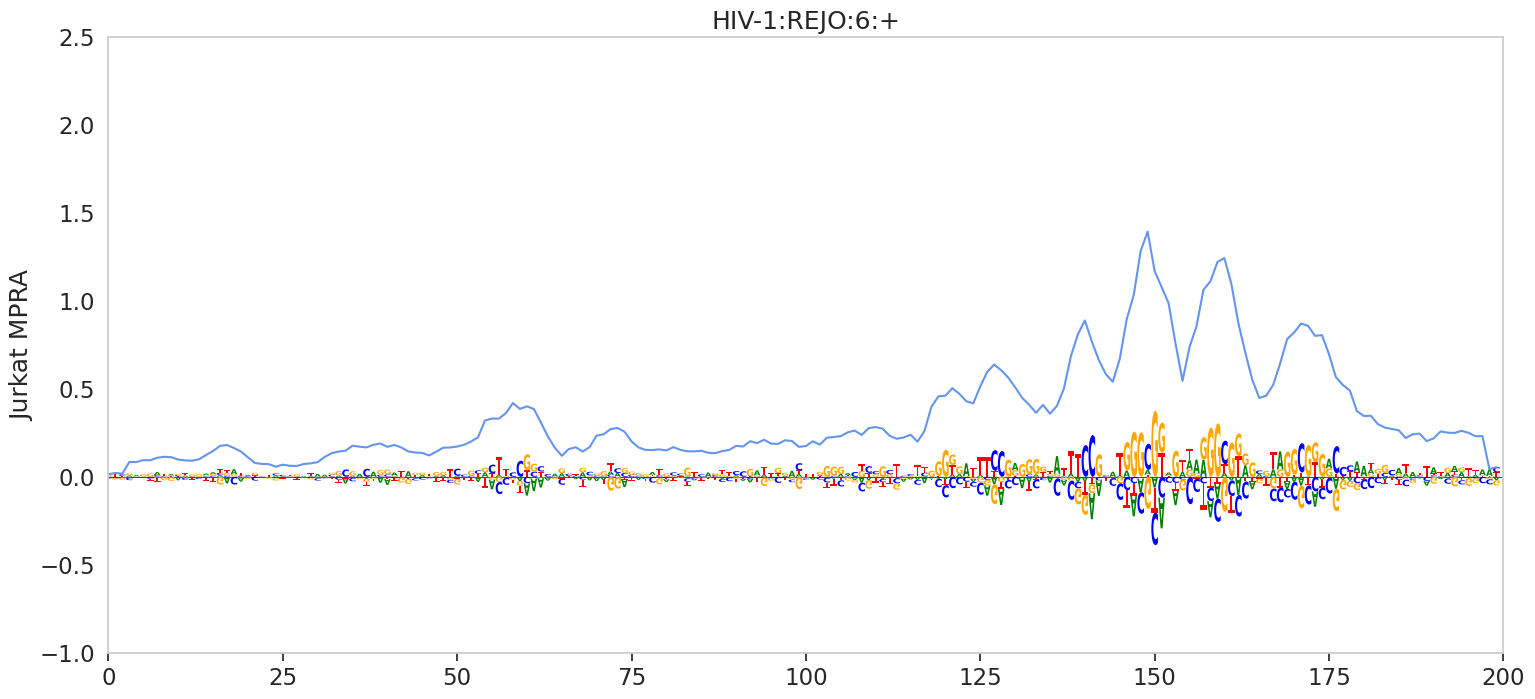

In [11]:
tile_index = 0
tile_id, tile_contrib_scores = valid_ids[tile_index], contribs[tile_index]
fig = plot_contribution_scores(tile_id, [tile_contrib_scores], ['Jurkat MPRA'])

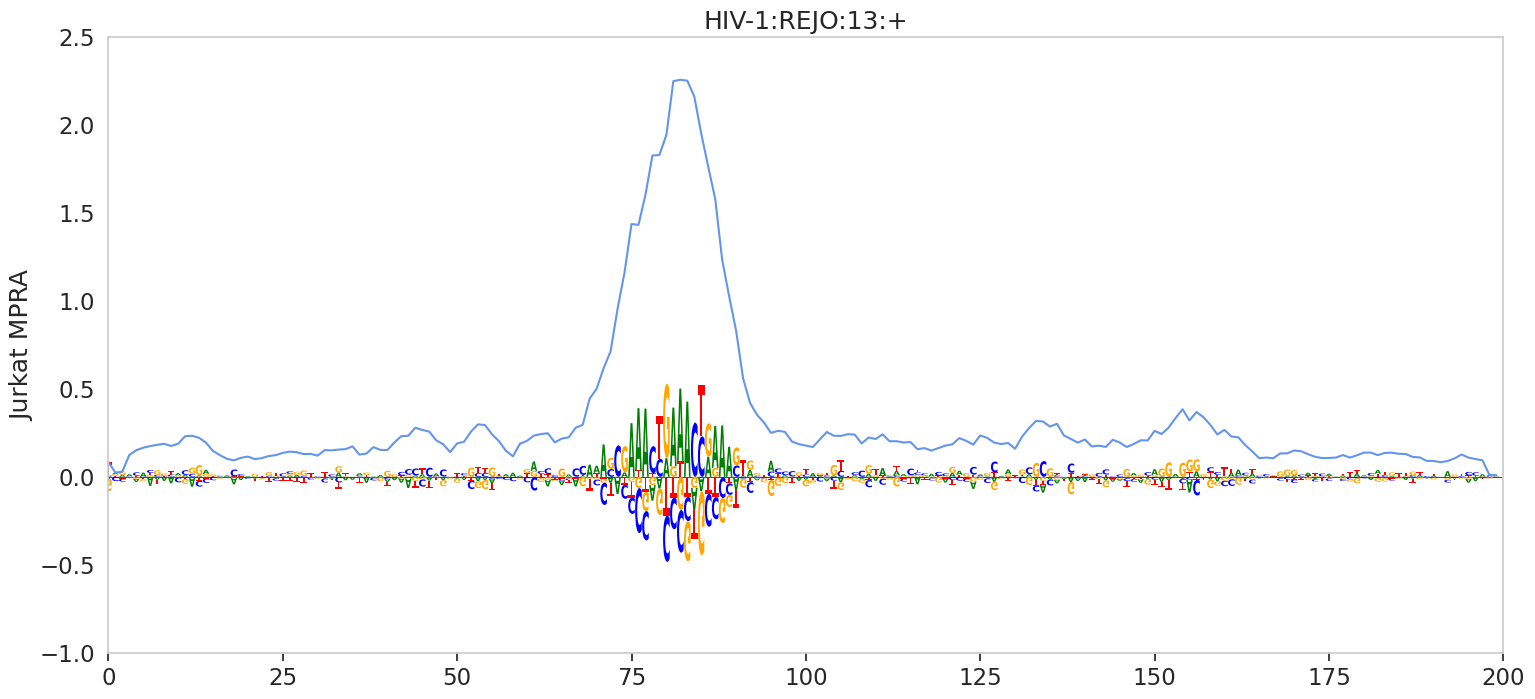

In [12]:
tile_index = 3
tile_id, tile_contrib_scores = valid_ids[tile_index], contribs[tile_index]
fig = plot_contribution_scores(tile_id, [tile_contrib_scores], ['Jurkat MPRA'])